# Data Visualization

**Import Necessary Python Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

### Load and Preview the Dataset

In [2]:
# Loading and Database connection

# read csv
df_csv = pd.read_csv("Exploratory_Data.csv")

# save to sql 
conn = sqlite3.connect("exploratory_data.db")
df_csv.to_sql("exploratory_data", conn, if_exists = "replace", index=False)

# Query from sql
df = pd.read_sql_query("select * from exploratory_data", conn)

# Display the first few rows of the dataset
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore,ConvertedCompYearly_Log,ExperienceLevel,Age_num
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/Elementary School,Books / Physical media,None,...,NaN,None,None,NaN,8.0,NaN,NaN,NaN,junior,17.0
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’S Degree (B.A., B.S., B.Eng., Etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,None,None,NaN,8.0,NaN,NaN,NaN,Senior,40.0
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’S Degree (M.A., M.S., M.Eng., Mba, Etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,Appropriate in length,Easy,NaN,8.0,NaN,NaN,NaN,Expert,50.0
3,4,I am learning to code,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Other...,Some College/University Study Without Earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,Too long,Easy,NaN,8.0,NaN,NaN,NaN,junior,21.0
4,5,I am a developer by profession,18-24 years old,"Student, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects;Other...,"Secondary School (E.G. American High School, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,Too short,Easy,NaN,8.0,NaN,NaN,NaN,junior,21.0


### Visualizing the distribution of data (Histograms)

Plot a histogram of CompTotal to visualize the distribution of respondents' total compensation.

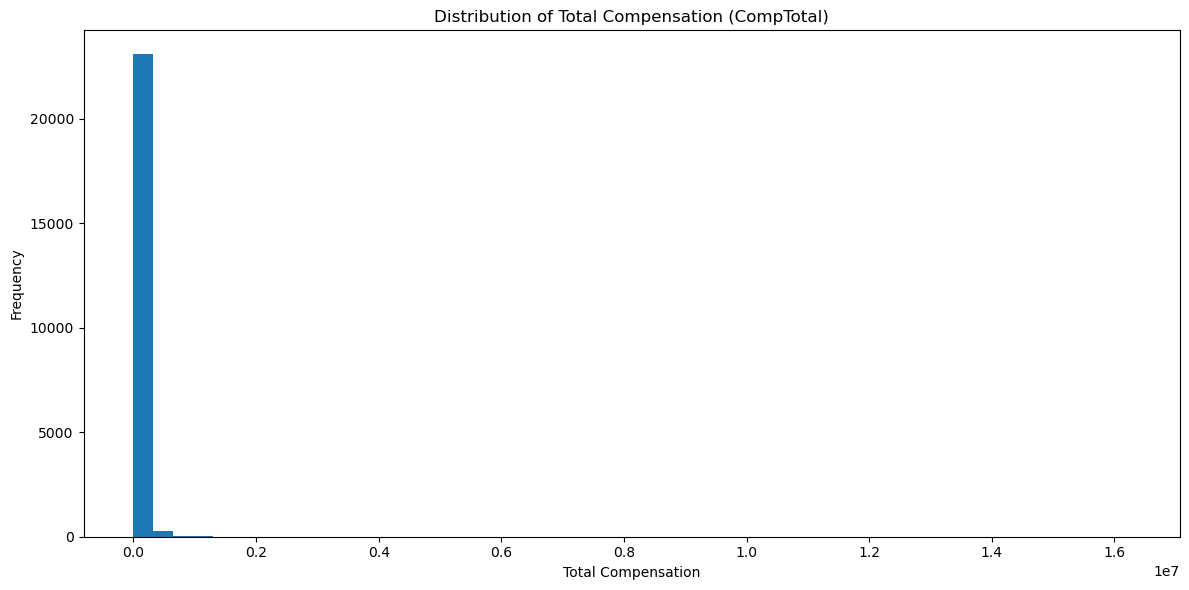

In [3]:
plt.figure(figsize=(12,6))
plt.hist(df["ConvertedCompYearly"].dropna(), bins=50)

plt.title("Distribution of Total Compensation (CompTotal)")
plt.xlabel("Total Compensation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Plot a histogram of YearsCodePro to analyze the distribution of coding experience among respondents

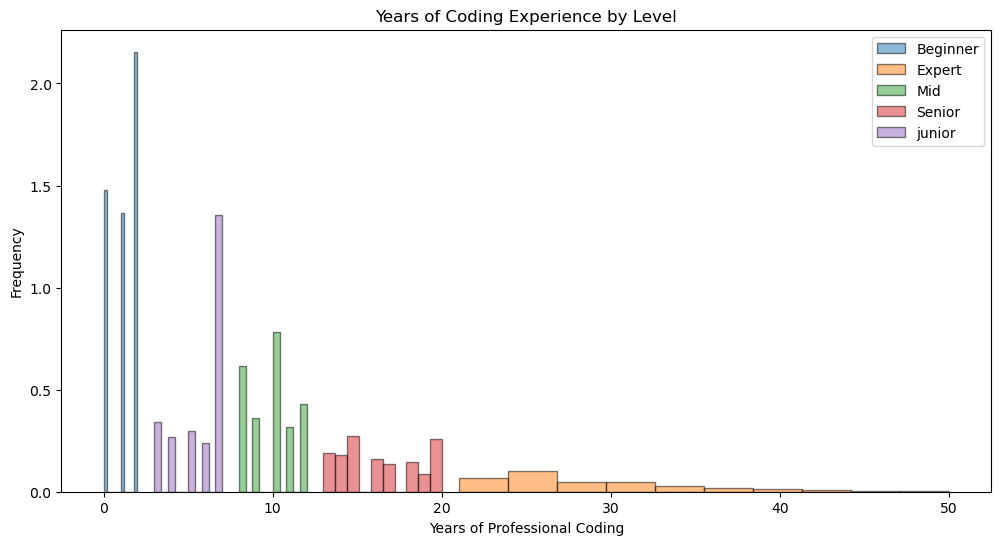

In [4]:
# plot the histogram 
plt.figure(figsize=(12,6))

for level, data in df.groupby("ExperienceLevel"):
    plt.hist(data["YearsCodePro"].dropna(), bins=10, alpha=0.5, label=level, edgecolor = "black", density=True)

plt.title("Years of Coding Experience by Level")
plt.xlabel("Years of Professional Coding")
plt.ylabel("Frequency")
plt.legend()

plt.show()

**Box Plot of Age**

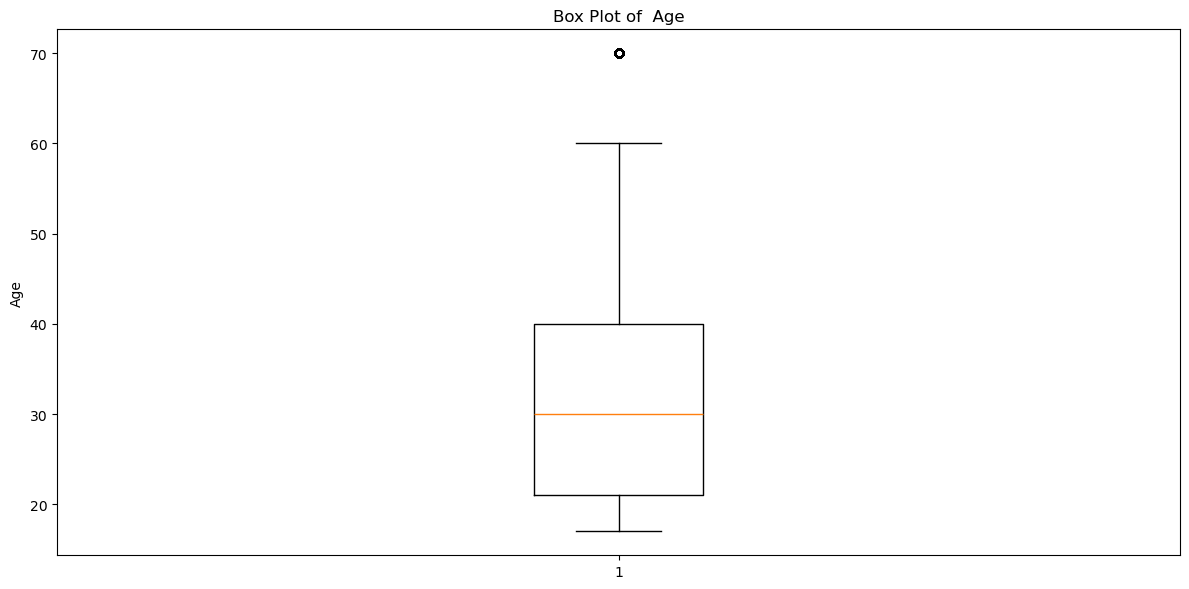

In [5]:
plt.figure(figsize=(12,6))
plt.boxplot(df["Age_num"].dropna(), vert=True)
plt.title("Box Plot of  Age")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

Box Plot of ConvertedCompYearly for the Top 5 Developer Types:

In [6]:
# Get top 5 developer types
top5_dev =df["DevType"].value_counts().head().index

# Filter only top 5 developer types
df_top5 = df[df["DevType"].isin(top5_dev)]

# Drop missing salary values
df_top5 = df_top5.dropna(subset=["ConvertedCompYearly"])

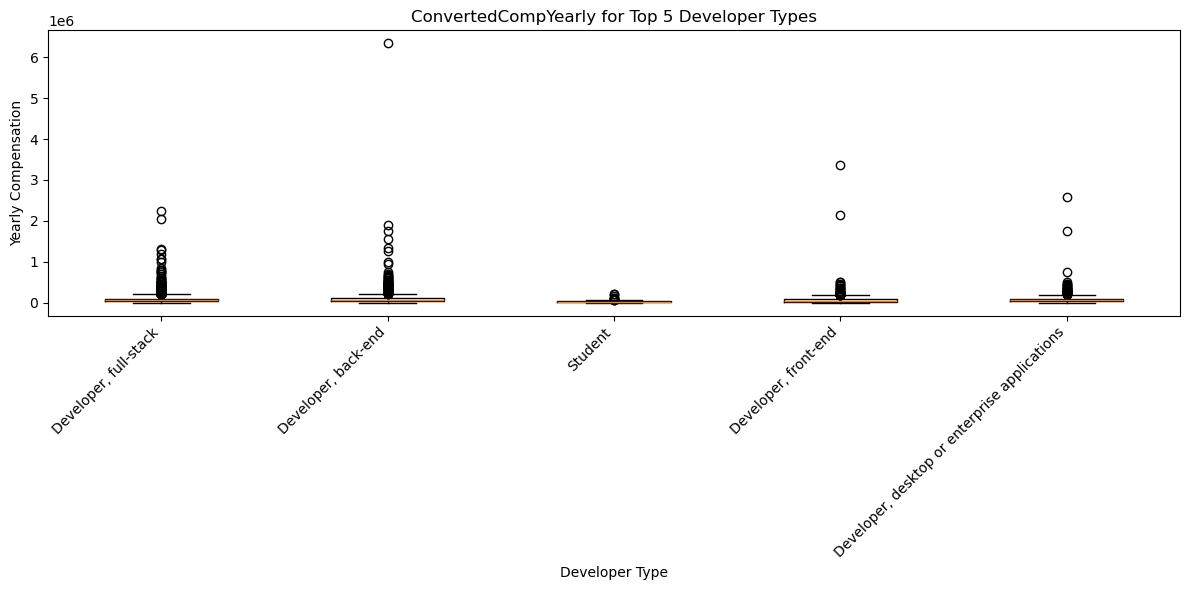

In [7]:
# Create box plot
plt.figure(figsize=(12,6))

# prepare data for box plot 
data = [df_top5[df_top5["DevType"]==dev]["ConvertedCompYearly"] for dev in top5_dev]

plt.boxplot(data)
plt.xticks(range(1, len(top5_dev)+1), top5_dev, rotation=45, ha = "right")

plt.title("ConvertedCompYearly for Top 5 Developer Types")
plt.ylabel("Yearly Compensation")
plt.xlabel("Developer Type")

plt.tight_layout()
plt.show()

Box Plot of CompTotal Across Employment Types

In [8]:
# Convert to numeric if needed
df["CompTotal"] = pd.to_numeric(df["CompTotal"], errors="coerce")

# Drop missing values
df_clean = df.dropna(subset=["CompTotal", "Employment"])

In [9]:
employment_types = df_clean["Employment"].head().unique()

data1 = [
    df_clean[df_clean["Employment"] == emp]["CompTotal"]
    for emp in employment_types
]

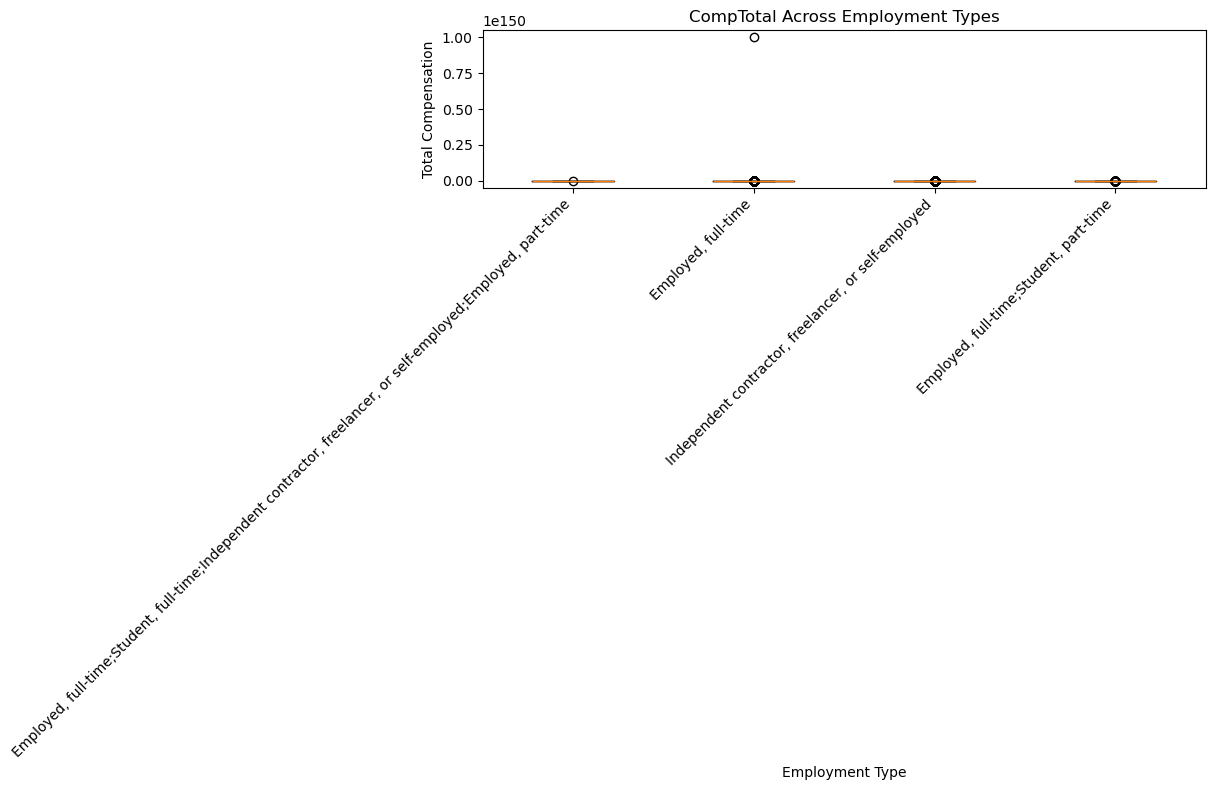

In [10]:
plt.figure(figsize=(12,8))   # Increase height

box = plt.boxplot(data1)

plt.xticks(range(1, len(employment_types)+1),employment_types,rotation=45,ha="right")

plt.title("CompTotal Across Employment Types")
plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")

plt.tight_layout()
plt.show()

**Scatter Plot for Compensation vs. Job Satisfaction**

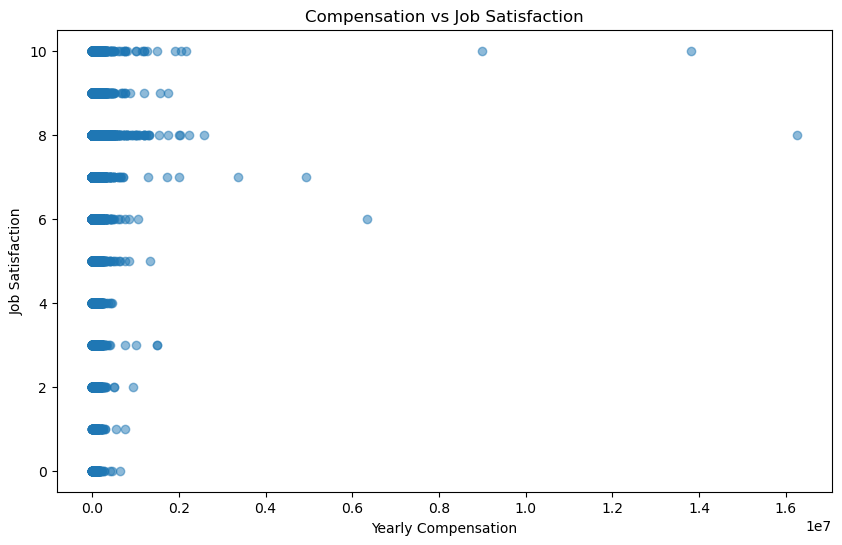

In [11]:
# Remove missing values
scatter_df = df.dropna(subset=["ConvertedCompYearly", "JobSat"])

plt.figure(figsize=(10,6))

plt.scatter(scatter_df["ConvertedCompYearly"],scatter_df["JobSat"],alpha=0.5)

plt.title("Compensation vs Job Satisfaction")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")

plt.show()

Scatter Plot for Popular Programming Languages by Job Satisfaction

In [12]:
# Drop missing values
lang_df = df.dropna(subset=["LanguageHaveWorkedWith", "JobSat"])

# Split multiple languages
lang_df = lang_df.assign(
    LanguageHaveWorkedWith=lang_df["LanguageHaveWorkedWith"].str.split(";")).explode("LanguageHaveWorkedWith")

top5_langs = (lang_df["LanguageHaveWorkedWith"].value_counts().head(5).index)

lang_top5 = lang_df[lang_df["LanguageHaveWorkedWith"].isin(top5_langs)]

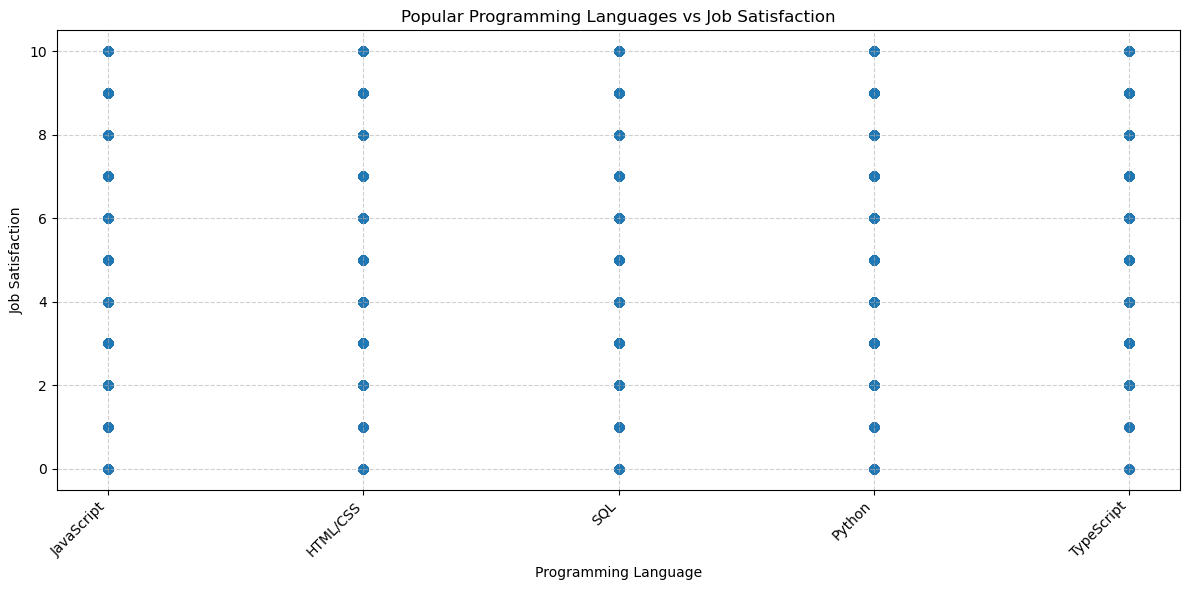

In [13]:
plt.figure(figsize=(12,6))

# Map languages to numbers (for x-axis positioning)
lang_positions = {lang: i for i, lang in enumerate(top5_langs)}

x = lang_top5["LanguageHaveWorkedWith"].map(lang_positions)
y = lang_top5["JobSat"]

plt.scatter(x, y, alpha=0.4)

plt.xticks(range(len(top5_langs)), top5_langs, rotation=45, ha="right")

plt.title("Popular Programming Languages vs Job Satisfaction")
plt.xlabel("Programming Language")
plt.ylabel("Job Satisfaction")

plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

**Bubble Plot of Technology Preferences by Age**

In [14]:
# Prepare the Data
# Remove missing values
bubble_df = df.dropna(subset=["Age", "LanguageHaveWorkedWith"])

# Split multiple languages
bubble_df = bubble_df.assign(
    LanguageHaveWorkedWith=bubble_df["LanguageHaveWorkedWith"].str.split(";")
).explode("LanguageHaveWorkedWith")

In [15]:
# Get Top 5 Languages (to keep chart readable)
top_langs = (bubble_df["LanguageHaveWorkedWith"]
    .value_counts()
    .head(5)
    .index
)

bubble_df = bubble_df[bubble_df["LanguageHaveWorkedWith"].isin(top_langs)]

In [16]:
# Create Frequency Table
freq_table = (
    bubble_df
    .groupby(["Age", "LanguageHaveWorkedWith"])
    .size()
    .reset_index(name="Count")
)

In [17]:
# Encode Age & Language for Plotting
age_groups = sorted(freq_table["Age"].unique())
lang_list = list(top_langs)

age_map = {age: i for i, age in enumerate(age_groups)}
lang_map = {lang: i for i, lang in enumerate(lang_list)}

freq_table["Age_num"] = freq_table["Age"].map(age_map)
freq_table["Lang_num"] = freq_table["LanguageHaveWorkedWith"].map(lang_map)

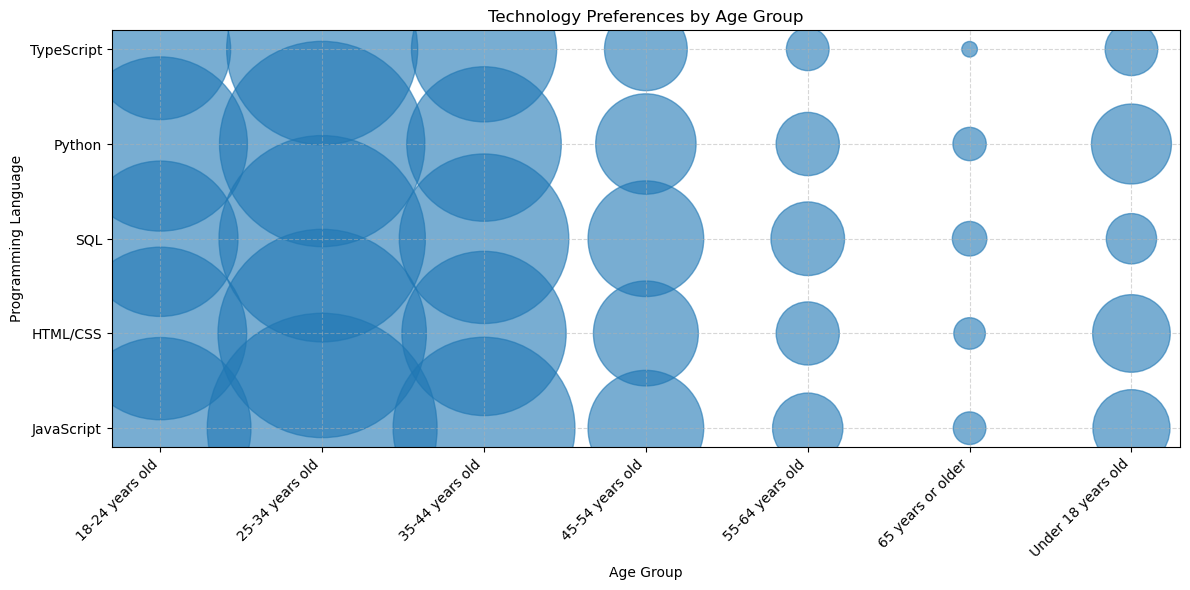

In [18]:
# Create Bubble Plot
plt.figure(figsize=(12,6))

plt.scatter(
    freq_table["Age_num"],
    freq_table["Lang_num"],
    s=freq_table["Count"] * 2 ,   # Bubble size scaling
    alpha=0.6
)

plt.xticks(range(len(age_groups)), age_groups, rotation=45, ha="right")
plt.yticks(range(len(lang_list)), lang_list)

plt.title("Technology Preferences by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Programming Language")

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Bubble Plot for Admired Technologies Across Countries

In [19]:
# Prepare the Data
# If multiple technologies are separated by semicolon (;)
df_expanded = df.dropna(subset=["LanguageAdmired"]).copy()

df_expanded["LanguageAdmired"] = df_expanded["LanguageAdmired"].str.split(";")
df_expanded = df_expanded.explode("LanguageAdmired")

# Count frequency
bubble_data = (
    df_expanded
    .groupby(["Country", "LanguageAdmired"])
    .size()
    .reset_index(name="Count")
)

In [20]:
# Top 10 countries
top_countries = bubble_data.groupby("Country")["Count"].sum().nlargest(10).index

# Top 10 admired technologies
top_techs = bubble_data.groupby("LanguageAdmired")["Count"].sum().nlargest(10).index

filtered_data = bubble_data[
    (bubble_data["Country"].isin(top_countries)) &
    (bubble_data["LanguageAdmired"].isin(top_techs))
]

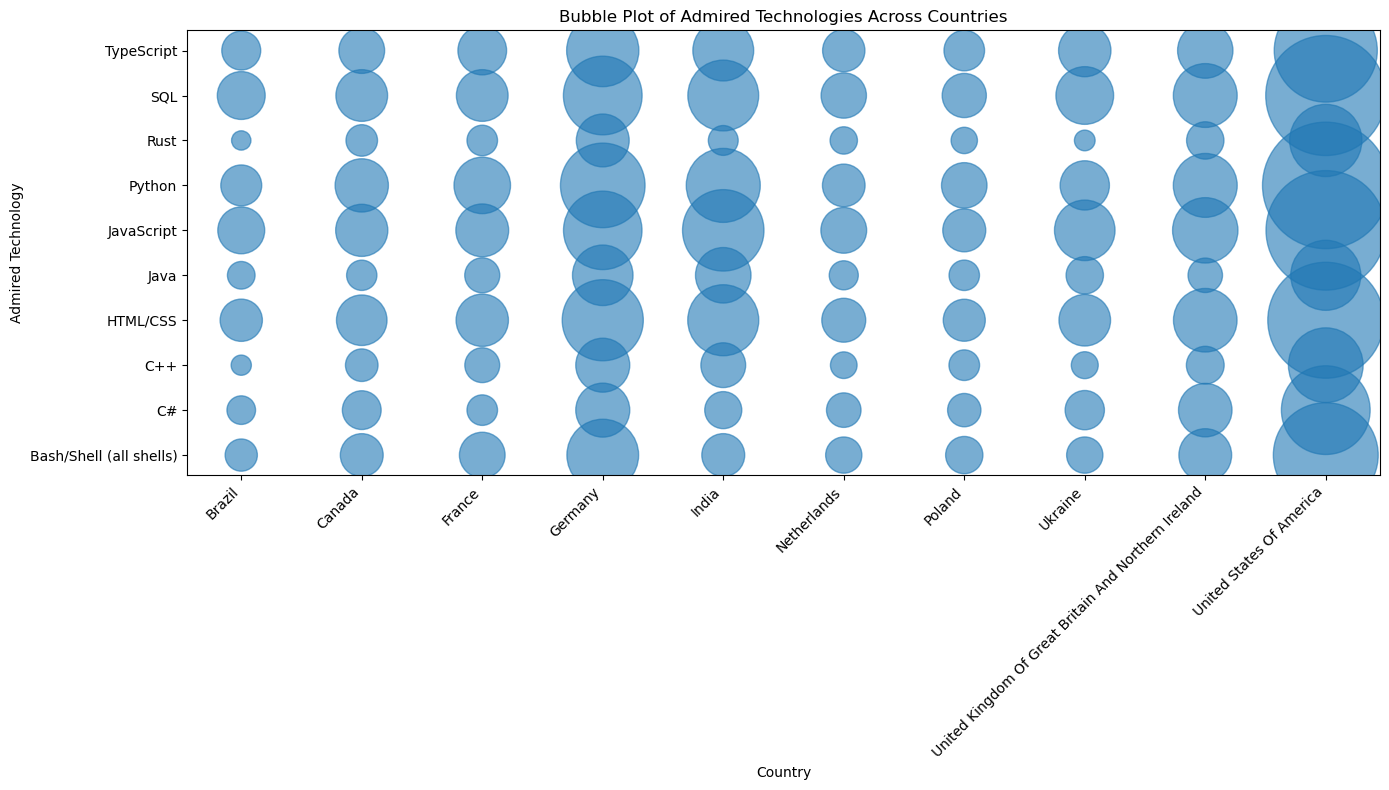

In [21]:
# Create the Bubble Plot
plt.figure(figsize=(14,8))

# Convert categorical values to numeric positions
countries = filtered_data["Country"].astype("category")
technologies = filtered_data["LanguageAdmired"].astype("category")

plt.scatter(
    countries.cat.codes,
    technologies.cat.codes,
    s=filtered_data["Count"] * 2,   # Bubble size scaling
    alpha=0.6
)

plt.xticks(range(len(countries.cat.categories)), countries.cat.categories, rotation=45, ha="right")
plt.yticks(range(len(technologies.cat.categories)), technologies.cat.categories)

plt.xlabel("Country")
plt.ylabel("Admired Technology")
plt.title("Bubble Plot of Admired Technologies Across Countries")

plt.tight_layout()
plt.show()


**Pie Chart for Top Collaboration Tools used in Professional Use**

In [22]:
# Prepare the Data
# Drop missing values
df_collab = df.dropna(subset=["NEWCollabToolsHaveWorkedWith"]).copy()

# Split multiple tools (assuming separated by ;)
df_collab["NEWCollabToolsHaveWorkedWith"] = (
    df_collab["NEWCollabToolsHaveWorkedWith"].str.split(";")
)

# Expand rows
df_collab = df_collab.explode("NEWCollabToolsHaveWorkedWith")

# Count frequency
tool_counts = df_collab["NEWCollabToolsHaveWorkedWith"].value_counts()

# Select Top 5 Tools
top5_tools = tool_counts.head(5)

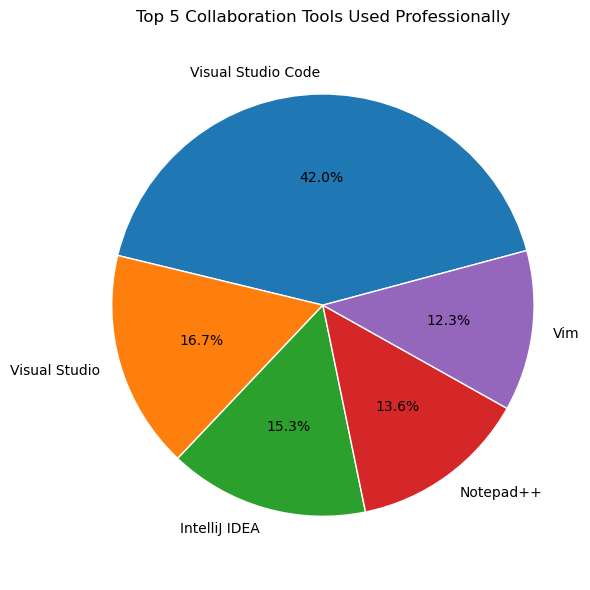

In [23]:
plt.figure(figsize=(6,6))

plt.pie(
    top5_tools.values,
    labels=top5_tools.index,
    autopct="%1.1f%%",
    startangle=15,
    wedgeprops={"edgecolor": "white"}
)

plt.title("Top 5 Collaboration Tools Used Professionally")
plt.axis("equal")   # Ensures circle shape
plt.tight_layout()
plt.show()

**Pie Chart for Preferred Web Frameworks**

Prepare the Data

In [24]:
# Drop missing values
df_web = df.dropna(subset=["WebframeWantToWorkWith"]).copy()

# Split multiple frameworks
df_web["WebframeWantToWorkWith"] = (
    df_web["WebframeWantToWorkWith"].str.split(";")
)

# Expand rows
df_web = df_web.explode("WebframeWantToWorkWith")

# Count frequency
framework_counts = df_web["WebframeWantToWorkWith"].value_counts()
# Select Top 5 Frameworks
top5_frameworks = framework_counts.head(5)

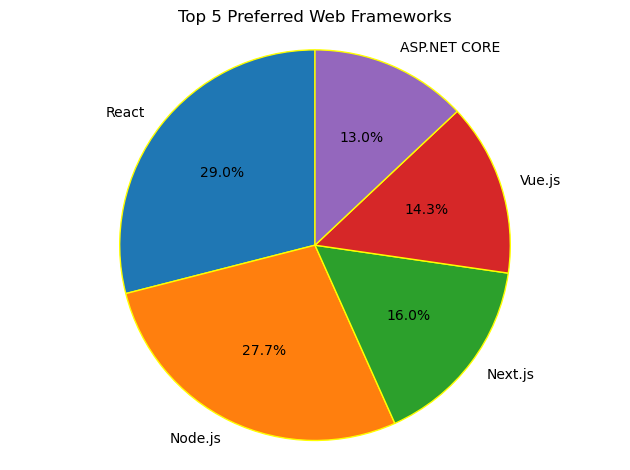

In [25]:
# Create the Pie Chart
plt.pie(
    top5_frameworks.values,
    labels=top5_frameworks.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "yellow"}
)

plt.title("Top 5 Preferred Web Frameworks")
plt.axis("equal")  # Makes it circular
plt.tight_layout()
plt.show()

**Stacked Chart for Compensation and Job Satisfaction by Age Group**

In [26]:
# Filter age 30–35
df_age = df[(df["Age_num"] >= 30) & (df["Age_num"] <= 35)]

In [38]:
# Clean Columns
# Convert compensation to numeric
df_age["ConvertedCompYearly"] = pd.to_numeric(df_age["ConvertedCompYearly"], errors="coerce")

# Drop missing values
df_age = df_age.dropna(subset=["ConvertedCompYearly", "JobSatPoints_6"])

In [28]:
# Aggregate Values

# Since compensation is large and satisfaction is small, we scale compensation.

# Calculate mean values
mean_comp = df_age["ConvertedCompYearly"].mean()
mean_sat = df_age["JobSatPoints_6"].mean()

# Scale compensation (divide by 1000 for readability)
mean_comp_scaled = mean_comp / 1000

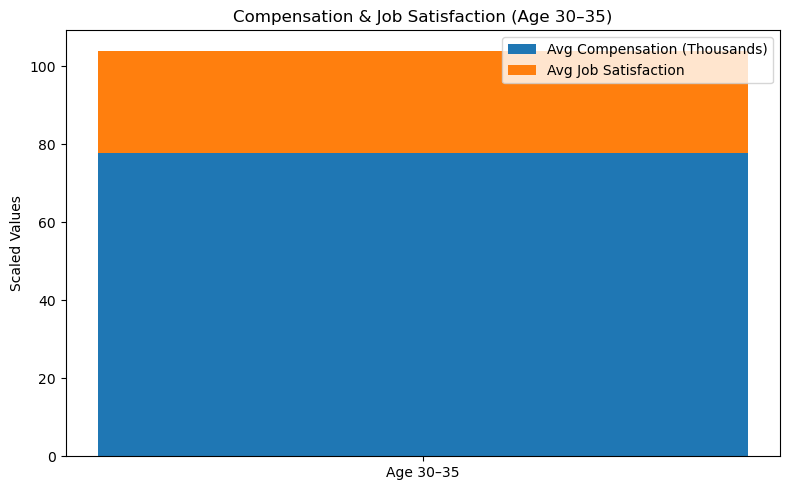

In [29]:
# Create Stacked Bar Chart
plt.figure(figsize=(8,5))

plt.bar(
    ["Age 30–35"],
    [mean_comp_scaled],
    label="Avg Compensation (Thousands)"
)

plt.bar(
    ["Age 30–35"],
    [mean_sat],
    bottom=[mean_comp_scaled],
    label="Avg Job Satisfaction"
)

plt.title("Compensation & Job Satisfaction (Age 30–35)")
plt.ylabel("Scaled Values")
plt.legend()

plt.tight_layout()
plt.show()

**Trends in Job Satisfaction and Compensation by Experience**

Line Chart of Median ConvertedCompYearly Over Experience Level

In [30]:
# Drop missing values
df_exp = df.dropna(subset=["ConvertedCompYearly", "WorkExp"]).copy()

In [31]:
# Group by Experience & Calculate Median Compensation
median_comp = (
    df_exp
    .groupby("WorkExp")["ConvertedCompYearly"]
    .median()
    .reset_index()
    .sort_values("WorkExp")
)

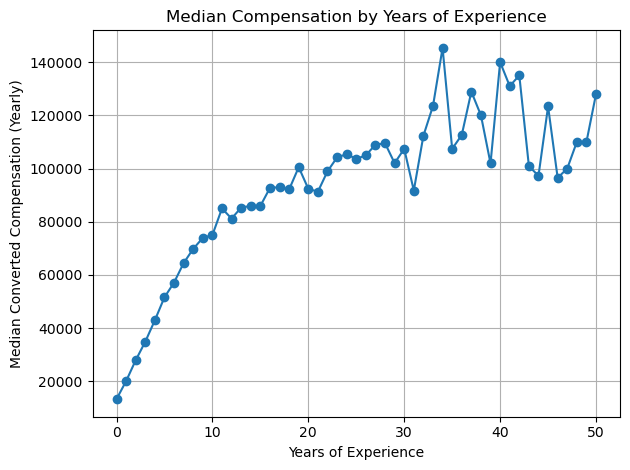

In [32]:
# Create Line Chart
plt.plot(
    median_comp["WorkExp"],
    median_comp["ConvertedCompYearly"],
    marker="o"
)

plt.title("Median Compensation by Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Median Converted Compensation (Yearly)")

plt.grid(True)
plt.tight_layout()
plt.show()

Line Chart of Median ConvertedCompYearly by Age Group

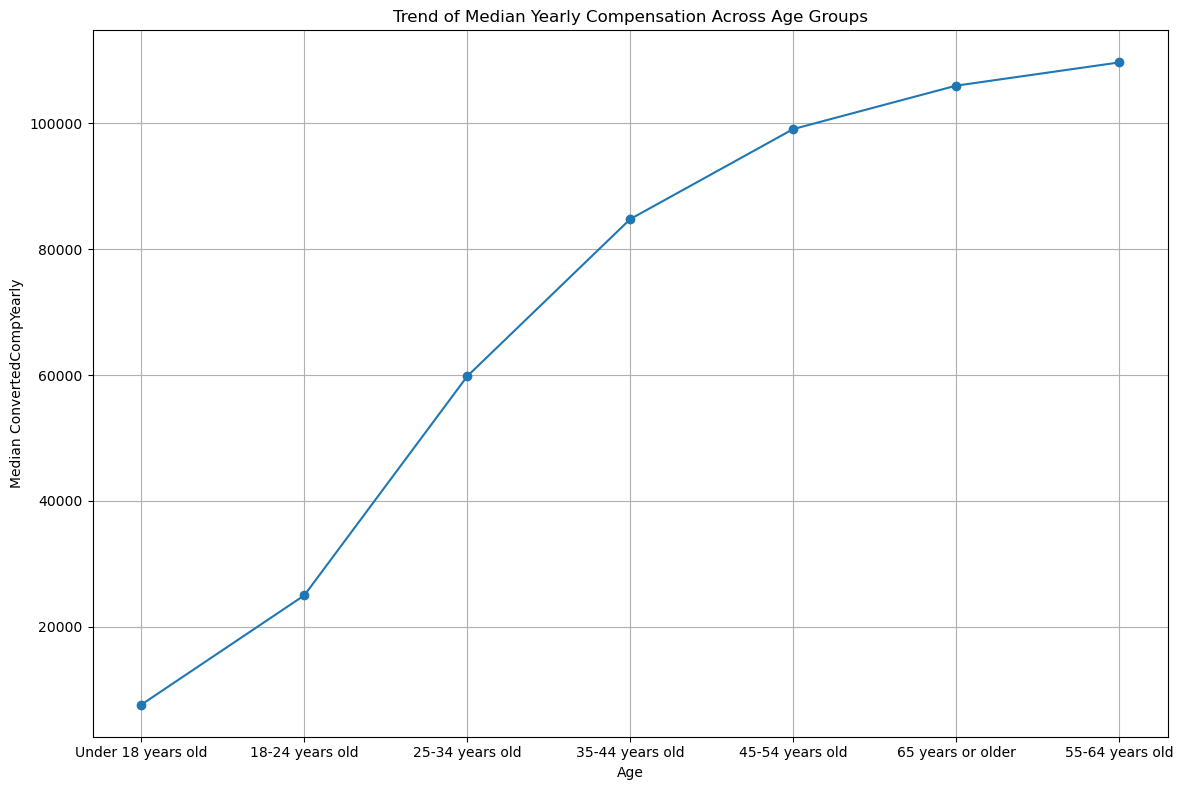

In [33]:
age_group= df.dropna(subset=["Age", "ConvertedCompYearly"])

median_age = age_group.groupby("Age")["ConvertedCompYearly"].median().sort_values(ascending=True)
plt.figure(figsize=(12,8))
plt.plot(median_age.index, median_age.values, marker="o")
plt.xlabel("Age")
plt.ylabel("Median ConvertedCompYearly")
plt.title("Trend of Median Yearly Compensation Across Age Groups")
plt.grid(True)
plt.tight_layout()
plt.show()

**Vertical Bar Chart of Top 5 Programming Languages Respondents Want to Work With**

In [34]:
# Prepare the Data
# Drop missing values
df_lang = df.dropna(subset=["LanguageWantToWorkWith"]).copy()

# Split multiple languages
df_lang["LanguageWantToWorkWith"] = (
    df_lang["LanguageWantToWorkWith"].str.split(";")
)

# Expand rows
df_lang = df_lang.explode("LanguageWantToWorkWith")

# Count frequency
language_counts = df_lang["LanguageWantToWorkWith"].value_counts()
top5_languages = language_counts.head(5)

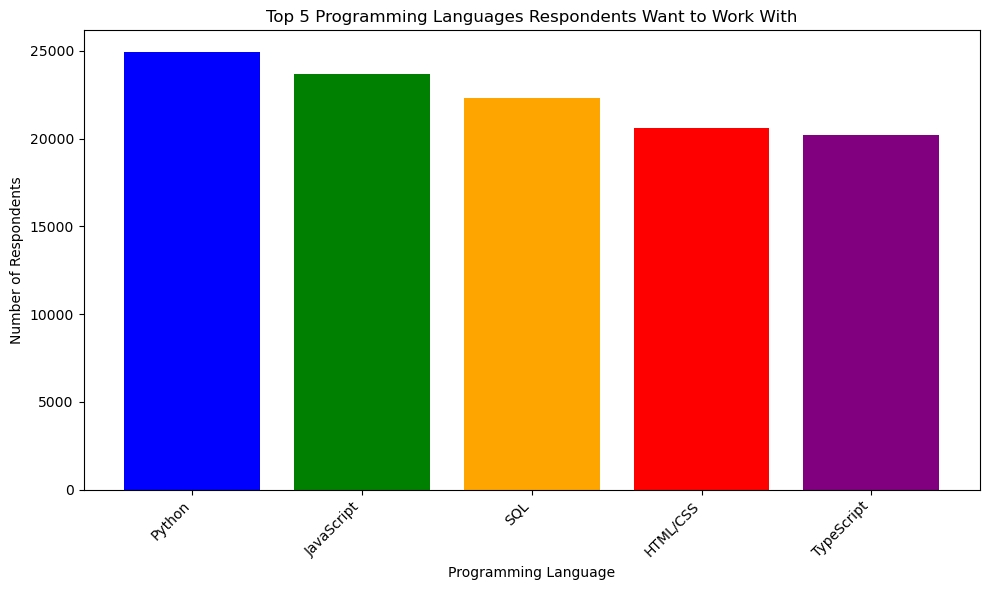

In [35]:
# Create Vertical Bar Chart
plt.figure(figsize=(10,6))

plt.bar(
    top5_languages.index,
    top5_languages.values,
    color=["blue", "green", "orange", "red", "purple"]
)

plt.title("Top 5 Programming Languages Respondents Want to Work With")
plt.xlabel("Programming Language")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

 Bar Chart of Respondent Count by Country

In [36]:
country_counts = df["Country"].value_counts()
top10_countries = country_counts.head(10)

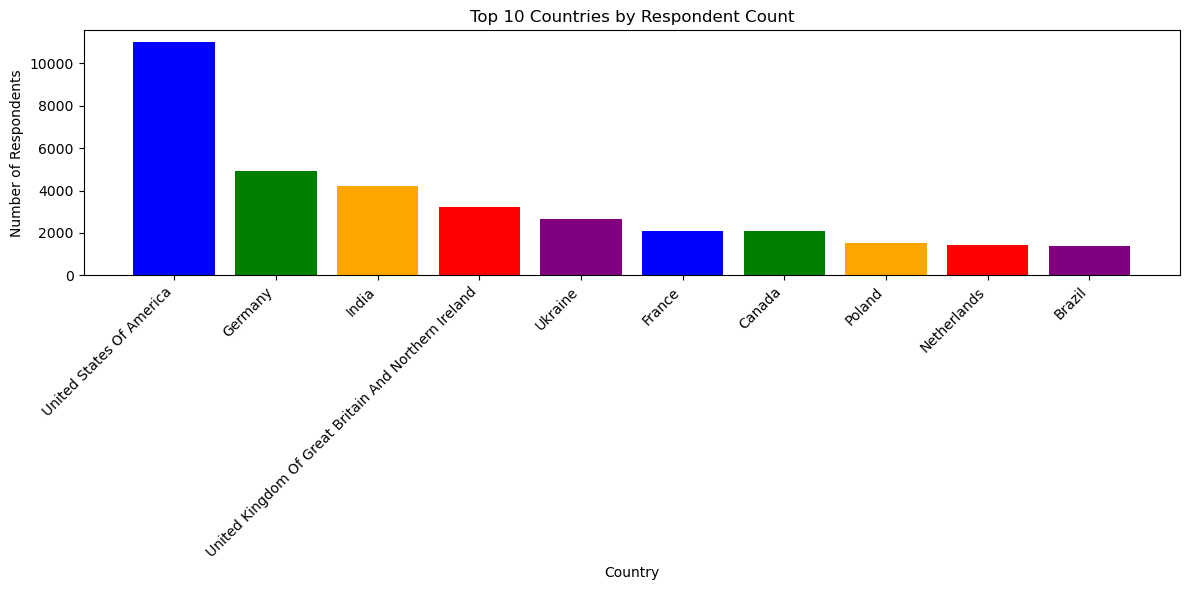

In [37]:
# Create Bar Chart
plt.figure(figsize=(12,6))

plt.bar(top10_countries.index,top10_countries.values, color = ["blue", "green", "orange", "red", "purple"])

plt.title("Top 10 Countries by Respondent Count")
plt.xlabel("Country")
plt.ylabel("Number of Respondents")

plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.